<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">🧹 Preprocesamiento de Datos</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 3 — Preparar los datos antes de entrenar un modelo</p>
</div>

Ningún modelo de Machine Learning puede compensar datos de mala calidad: valores faltantes, escalas inconsistentes entre variables, categorías sin codificar o variables redundantes afectan directamente su desempeño. El **preprocesamiento de datos** es el conjunto de técnicas que transforma los datos "crudos" en una forma adecuada para entrenar un modelo.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#dataset">El dataset de trabajo: generación y división train/test</a></li>
<li><a href="#limpieza">Limpieza y tratamiento de valores faltantes</a></li>
<li><a href="#outliers">Detección y tratamiento de outliers</a></li>
<li><a href="#transformacion">Transformación de datos</a></li>
<li><a href="#escalado">Escalado y normalización</a></li>
<li><a href="#codificacion">Codificación de variables categóricas</a></li>
<li><a href="#pca">Reducción de dimensionalidad (PCA)</a></li>
<li><a href="#preparacion">Validación adicional (cross-validation y train/val/test)</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Una regla fundamental que aplica a casi todas las técnicas de esta guía (imputación, escalado, codificación): en un proyecto real, estas transformaciones se <strong>ajustan (<code>fit</code>) únicamente con los datos de entrenamiento</strong>, y luego se aplican (<code>transform</code>) tanto a entrenamiento como a prueba con esos mismos parámetros. Ajustarlas con el dataset completo antes de dividirlo filtra información del conjunto de prueba hacia el entrenamiento (<em>data leakage</em>), lo que produce una evaluación del modelo demasiado optimista. A diferencia de una versión anterior de esta guía, aquí se construye <strong>un único dataset</strong>, se divide en entrenamiento y prueba <strong>desde el principio</strong>, y cada técnica se aplica correctamente sobre esa división, para que el efecto de esta regla se pueda observar de forma concreta en cada sección.
</div>

<a id="dataset"></a>

# <span style="color:#F97066;">1.</span> El dataset de trabajo

A lo largo de esta guía se utiliza un único conjunto de datos sintético: solicitudes de un producto de crédito bancario. Se generó deliberadamente para contener los elementos que se abordan en cada sección: valores faltantes, outliers genuinos, variables numéricas correlacionadas entre sí, una variable categórica nominal y una ordinal, y una variable objetivo binaria.

<div style="border-radius:12px; overflow:hidden; border:1px solid rgba(14,165,233,0.35); margin:16px 0;">
<table style="width:100%; border-collapse:collapse; font-size:0.95em;">
<thead>
<tr style="background:#0EA5E9;">
<th style="text-align:left; padding:10px 14px; color:#ffffff;">Columna</th>
<th style="text-align:left; padding:10px 14px; color:#ffffff;">Tipo</th>
<th style="text-align:left; padding:10px 14px; color:#ffffff;">Descripción</th>
</tr>
</thead>
<tbody>
<tr style="background:rgba(14,165,233,0.07);">
<td style="padding:10px 14px;"><code>edad</code></td>
<td style="padding:10px 14px;">Numérica</td>
<td style="padding:10px 14px;">Edad del solicitante, en años.</td>
</tr>
<tr>
<td style="padding:10px 14px;"><code>ingreso_anual</code></td>
<td style="padding:10px 14px;">Numérica</td>
<td style="padding:10px 14px;">Ingreso anual declarado (con valores faltantes y outliers).</td>
</tr>
<tr style="background:rgba(14,165,233,0.07);">
<td style="padding:10px 14px;"><code>antiguedad_laboral</code></td>
<td style="padding:10px 14px;">Numérica</td>
<td style="padding:10px 14px;">Años en el empleo actual (con valores faltantes).</td>
</tr>
<tr>
<td style="padding:10px 14px;"><code>puntaje_crediticio</code></td>
<td style="padding:10px 14px;">Numérica</td>
<td style="padding:10px 14px;">Puntaje crediticio (300-850).</td>
</tr>
<tr style="background:rgba(14,165,233,0.07);">
<td style="padding:10px 14px;"><code>ciudad</code></td>
<td style="padding:10px 14px;">Categórica nominal</td>
<td style="padding:10px 14px;">Ciudad de residencia (con valores faltantes).</td>
</tr>
<tr>
<td style="padding:10px 14px;"><code>nivel_educativo</code></td>
<td style="padding:10px 14px;">Categórica ordinal</td>
<td style="padding:10px 14px;">Secundaria &lt; Pregrado &lt; Posgrado.</td>
</tr>
<tr style="background:rgba(14,165,233,0.07);">
<td style="padding:10px 14px;"><code>aprobado</code></td>
<td style="padding:10px 14px;">Objetivo (0/1)</td>
<td style="padding:10px 14px;">Si la solicitud de crédito fue aprobada.</td>
</tr>
</tbody>
</table>
</div>

In [43]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 300

# --- Variables numéricas, correlacionadas entre sí como en un caso real ---
edad = np.random.randint(18, 70, size=n).astype(float)

# La antigüedad laboral tiende a ser mayor cuanto mayor es la edad, con ruido
antiguedad_laboral = np.clip((edad - 18) * 0.18 + np.random.exponential(scale=2.0, size=n), 0, None)
antiguedad_laboral = np.round(antiguedad_laboral, 1)

# El ingreso anual tiende a ser mayor con más antigüedad y edad (log-normal + ruido)
base_log_ingreso = 9.9 + 0.03 * antiguedad_laboral + 0.004 * edad
ingreso_anual = np.round(np.exp(base_log_ingreso + np.random.normal(0, 0.28, size=n)))

# Outliers genuinos: un pequeño grupo con ingresos excepcionalmente altos
idx_outliers = np.random.choice(n, size=6, replace=False)
ingreso_anual[idx_outliers] = ingreso_anual[idx_outliers] * 7

# El puntaje crediticio tiende a ser mayor con mayor ingreso y antigüedad
puntaje_crediticio = (
    520 + 0.0016 * np.clip(ingreso_anual, 0, 120000) + 4.5 * antiguedad_laboral
    + np.random.normal(0, 35, size=n)
)
puntaje_crediticio = np.round(np.clip(puntaje_crediticio, 300, 850))

# --- Variables categóricas ---
ciudad = np.random.choice(["Bogotá", "Medellín", "Cali", "Barranquilla"], size=n, p=[0.4, 0.3, 0.2, 0.1])
nivel_educativo = np.random.choice(["Secundaria", "Pregrado", "Posgrado"], size=n, p=[0.3, 0.5, 0.2])

# --- Variable objetivo: aprobación de crédito ---
z = (
    -12.0
    + 0.016 * puntaje_crediticio
    + 0.00007 * np.clip(ingreso_anual, 0, 120000)
    + 0.09 * antiguedad_laboral
)
prob_aprobacion = 1 / (1 + np.exp(-z))
aprobado = np.random.binomial(1, prob_aprobacion)

df = pd.DataFrame({
    "edad": edad,
    "ingreso_anual": ingreso_anual,
    "antiguedad_laboral": antiguedad_laboral,
    "puntaje_crediticio": puntaje_crediticio,
    "ciudad": ciudad,
    "nivel_educativo": nivel_educativo,
    "aprobado": aprobado,
})

# Inyectar valores faltantes de forma realista
for col, frac in [("ingreso_anual", 0.06), ("antiguedad_laboral", 0.05), ("ciudad", 0.04)]:
    idx = np.random.choice(n, size=int(round(n * frac)), replace=False)
    df.loc[idx, col] = np.nan

df.head()

,edad,ingreso_anual,antiguedad_laboral,puntaje_crediticio,ciudad,nivel_educativo,aprobado
0,56.0,39599.0,11.1,596.0,Cali,Pregrado,1
1,69.0,26175.0,9.6,629.0,Medellín,Pregrado,0
2,46.0,19464.0,5.7,571.0,Cali,Pregrado,0
3,32.0,22441.0,4.9,549.0,Cali,Posgrado,0
4,60.0,28438.0,11.3,697.0,Medellín,Posgrado,1


Antes de aplicar cualquier técnica de limpieza o transformación, se separan las **características** (`X`) del **objetivo** (`y`) y se divide el dataset en entrenamiento y prueba. Esto se hace primero, con los datos aún "crudos" (con valores faltantes incluidos), precisamente para que cada técnica posterior pueda ajustarse solo con el conjunto de entrenamiento.

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Ejecute la siguiente celda. El parámetro `stratify=y` asegura que la proporción de solicitudes aprobadas/rechazadas sea similar en ambos conjuntos.

In [44]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["aprobado"])
y = df["aprobado"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")
print()
print("Proporción de 'aprobado' en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

Entrenamiento: 240 filas
Prueba: 60 filas

Proporción de 'aprobado' en entrenamiento:
aprobado
1    0.542
0    0.458
Name: proportion, dtype: float64


---

<a id="limpieza"></a>

# <span style="color:#F97066;">2.</span> Limpieza y tratamiento de valores faltantes

Los valores faltantes (`None` o `NaN`) son uno de los problemas más comunes en datos reales. Existen dos estrategias principales para tratarlos: **eliminarlos** o **imputarlos** (reemplazarlos por un valor estimado). A partir de aquí, todo el análisis se realiza sobre `X_train`; `X_test` solo se toca para *aplicar* (nunca para *ajustar*) cada transformación.

In [45]:
# Valores faltantes en el conjunto de entrenamiento
X_train.isnull().sum()

edad                   0
ingreso_anual         13
antiguedad_laboral    14
puntaje_crediticio     0
ciudad                 8
nivel_educativo        0
dtype: int64

### Eliminación con `dropna()`

La forma más simple de tratar valores faltantes es eliminar las filas (o columnas) que los contienen. Es fácil de aplicar, pero descarta información; con muchas columnas con valores faltantes dispersos, puede eliminar una porción importante del dataset.

In [46]:
print(f"Filas en entrenamiento antes de eliminar: {X_train.shape[0]}")
print(f"Filas en entrenamiento después de eliminar (dropna): {X_train.dropna().shape[0]}")

Filas en entrenamiento antes de eliminar: 240
Filas en entrenamiento después de eliminar (dropna): 205


### Imputación

En lugar de descartar filas, la **imputación** reemplaza cada valor faltante por una estimación: la **media** para variables numéricas, o la **moda** (el valor más frecuente) para variables categóricas. El imputador se ajusta (`fit`) únicamente con `X_train`, y ese mismo valor aprendido (la media/moda del entrenamiento) se usa para completar tanto `X_train` como `X_test`.

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Ejecute la siguiente celda y confirme que, tras la imputación, ya no quedan valores nulos en ninguno de los dos conjuntos.

In [47]:
from sklearn.impute import SimpleImputer

# Imputación con la media para las columnas numéricas con valores faltantes
cols_numericas = ["ingreso_anual", "antiguedad_laboral"]
imputer_media = SimpleImputer(strategy="mean")
imputer_media.fit(X_train[cols_numericas])  # Se ajusta SOLO con entrenamiento

X_train[cols_numericas] = imputer_media.transform(X_train[cols_numericas])
X_test[cols_numericas] = imputer_media.transform(X_test[cols_numericas])

# Imputación con la moda para la columna categórica con valores faltantes
imputer_moda = SimpleImputer(strategy="most_frequent")
imputer_moda.fit(X_train[["ciudad"]])  # Se ajusta SOLO con entrenamiento

X_train[["ciudad"]] = imputer_moda.transform(X_train[["ciudad"]])
X_test[["ciudad"]] = imputer_moda.transform(X_test[["ciudad"]])

print("Valores nulos restantes en entrenamiento:", X_train.isnull().sum().sum())
print("Valores nulos restantes en prueba:", X_test.isnull().sum().sum())

Valores nulos restantes en entrenamiento: 0
Valores nulos restantes en prueba: 0


---

<a id="outliers"></a>

# <span style="color:#F97066;">3.</span> Detección y tratamiento de outliers

Un **outlier** (valor atípico) es una observación que se aleja notablemente del resto de los datos. Pueden ser errores de medición o captura, o valores genuinos pero extremos (como los ingresos excepcionalmente altos incluidos deliberadamente en `ingreso_anual`); en ambos casos, pueden distorsionar estadísticas como la media o afectar negativamente a modelos sensibles a la escala de los datos.

### Método estadístico: Z-score

El **Z-score** mide a cuántas desviaciones estándar se encuentra un valor respecto a la media. Un criterio habitual es considerar outlier a todo valor con $|Z| > 3$. El Z-score se calcula únicamente con la media y desviación estándar del **entrenamiento**.

In [49]:
from scipy.stats import zscore

z_scores = zscore(X_train["ingreso_anual"])
outliers = X_train[np.abs(z_scores) > 3]

print(f"Outliers detectados en 'ingreso_anual' (entrenamiento): {len(outliers)}")
outliers[["ingreso_anual"]]

Outliers detectados en 'ingreso_anual' (entrenamiento): 3


,ingreso_anual
115,266315.0
37,205464.0
159,398090.0


### Método gráfico: Boxplot

El boxplot ofrece una forma visual de identificar outliers: los puntos que aparecen fuera de los "bigotes" de la caja se consideran atípicos según el criterio del rango intercuartílico (IQR), que se aplica a continuación.

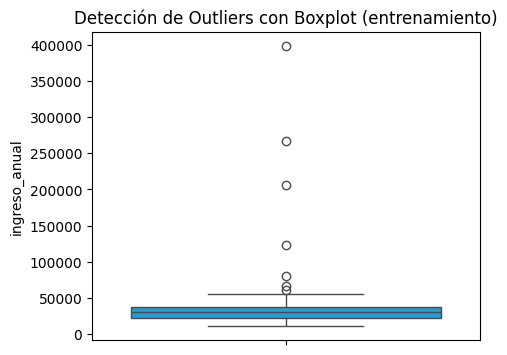

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.boxplot(data=X_train["ingreso_anual"], color="#0EA5E9")
plt.title("Detección de Outliers con Boxplot (entrenamiento)")
plt.ylabel("ingreso_anual")
plt.show()

### Tratamiento de outliers: eliminación con IQR

El **rango intercuartílico** (IQR = Q3 - Q1) define un rango aceptable de valores: todo lo que caiga por debajo de $Q1 - 1.5 \times IQR$ o por encima de $Q3 + 1.5 \times IQR$ se considera outlier.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
A diferencia de la imputación o el escalado, la <strong>eliminación</strong> de outliers normalmente solo se aplica al conjunto de <strong>entrenamiento</strong>. El conjunto de prueba debe reflejar los datos tal como llegarían en producción (outliers incluidos); filtrarlo también artificialmente facilitaría la evaluación del modelo de forma poco realista.
</div>

In [51]:
Q1, Q3 = np.percentile(X_train["ingreso_anual"], [25, 75])
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

mask_sin_outliers = (X_train["ingreso_anual"] >= limite_inferior) & (X_train["ingreso_anual"] <= limite_superior)

print(f"Límite inferior: {limite_inferior:.0f} | Límite superior: {limite_superior:.0f}")
print(f"Filas de entrenamiento dentro del rango aceptable: {mask_sin_outliers.sum()} de {len(X_train)}")

Límite inferior: 1138 | Límite superior: 58454
Filas de entrenamiento dentro del rango aceptable: 233 de 240


---

<a id="transformacion"></a>

# <span style="color:#F97066;">4.</span> Transformación de datos

Además de eliminar outliers, es posible **transformar** una variable para reducir su impacto sin descartar observaciones.

### 4.1 Escalado logarítmico

Aplicar $\log(x + 1)$ comprime los valores grandes mucho más que los pequeños, reduciendo la influencia de valores extremos. Al ser una fórmula fija (no aprende parámetros de los datos), puede aplicarse directamente tanto a entrenamiento como a prueba sin riesgo de fuga de información.

In [52]:
ingreso_train_log = np.log(X_train["ingreso_anual"] + 1)
ingreso_test_log = np.log(X_test["ingreso_anual"] + 1)

ingreso_train_log.describe()

count    240.000000
mean      10.319213
std        0.436032
min        9.307649
25%       10.027124
50%       10.312612
75%       10.517612
max       12.894436
Name: ingreso_anual, dtype: float64

### 4.2 Winsorización

En lugar de eliminar los valores extremos, la **winsorización** los recorta: reemplaza los valores por debajo del percentil 5 o por encima del percentil 95 por el valor de ese percentil. A diferencia de la función `scipy.stats.mstats.winsorize()` (que calcula los percentiles sobre el mismo array que recibe), aquí los percentiles se calculan **solo con el entrenamiento** y ese mismo límite fijo se aplica después al conjunto de prueba, para evitar que este último "informe" su propio recorte.

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Ejecute la celda y observe cómo el valor máximo del conjunto de <strong>prueba</strong> también queda acotado por el límite aprendido del entrenamiento, aunque su outlier original era distinto.

In [53]:
p05, p95 = np.percentile(X_train["ingreso_anual"], [5, 95])  # Límites calculados SOLO con entrenamiento

ingreso_train_winsorizado = X_train["ingreso_anual"].clip(lower=p05, upper=p95)
ingreso_test_winsorizado = X_test["ingreso_anual"].clip(lower=p05, upper=p95)

print(f"Límites aprendidos del entrenamiento: [{p05:.0f}, {p95:.0f}]")
print(f"Máximo en entrenamiento, antes -> después: {X_train['ingreso_anual'].max():.0f} -> {ingreso_train_winsorizado.max():.0f}")
print(f"Máximo en prueba, antes -> después: {X_test['ingreso_anual'].max():.0f} -> {ingreso_test_winsorizado.max():.0f}")

Límites aprendidos del entrenamiento: [16433, 51598]
Máximo en entrenamiento, antes -> después: 398090 -> 51598
Máximo en prueba, antes -> después: 266161 -> 51598


---

<a id="escalado"></a>

# <span style="color:#F97066;">5.</span> Escalado y normalización

Muchos algoritmos (por ejemplo, los basados en distancias, como K-Vecinos, o en descenso de gradiente) son sensibles a la **escala** de las variables: si una variable se mide en miles y otra en unidades, la de mayor magnitud puede dominar el cálculo sin ser realmente más importante.

### 5.1 Normalización (Min-Max Scaling)

Reescala cada variable a un rango fijo, típicamente $[0, 1]$, mediante $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$. Los valores mínimo y máximo se toman del **entrenamiento**.

In [54]:
from sklearn.preprocessing import MinMaxScaler

cols_numericas_todas = ["edad", "ingreso_anual", "antiguedad_laboral", "puntaje_crediticio"]

minmax_scaler = MinMaxScaler()
minmax_scaler.fit(X_train[cols_numericas_todas])  # Se ajusta SOLO con entrenamiento

X_train_minmax = pd.DataFrame(
    minmax_scaler.transform(X_train[cols_numericas_todas]), columns=cols_numericas_todas, index=X_train.index
)
X_test_minmax = pd.DataFrame(
    minmax_scaler.transform(X_test[cols_numericas_todas]), columns=cols_numericas_todas, index=X_test.index
)

print("Entrenamiento normalizado (min/max):")
print(X_train_minmax.describe().loc[["min", "max"]].round(2))
print("\nPrueba normalizada (min/max, puede exceder [0, 1] si hay valores más extremos que en entrenamiento):")
print(X_test_minmax.describe().loc[["min", "max"]].round(2))

Entrenamiento normalizado (min/max):
     edad  ingreso_anual  antiguedad_laboral  puntaje_crediticio
min   0.0            0.0                 0.0                 0.0
max   1.0            1.0                 1.0                 1.0

Prueba normalizada (min/max, puede exceder [0, 1] si hay valores más extremos que en entrenamiento):
     edad  ingreso_anual  antiguedad_laboral  puntaje_crediticio
min  0.00           0.01                0.01                0.12
max  0.98           0.66                0.70                1.09


### 5.2 Estandarización (Z-score Scaling)

Reescala cada variable para que tenga **media 0 y desviación estándar 1**, mediante $x' = \frac{x - \mu}{\sigma}$, usando la media ($\mu$) y desviación estándar ($\sigma$) del **entrenamiento**. Es el escalado más usado en la práctica, y es el que se utilizará más adelante para PCA.

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Ejecute la celda y observe que, como se esperaba, la media del entrenamiento escalado es 0. La media del conjunto de <strong>prueba</strong> escalado, en cambio, <strong>no</strong> es exactamente 0: esto es normal y esperado, ya que la prueba se transformó con la media y desviación del entrenamiento, no con las suyas propias.

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[cols_numericas_todas])  # Se ajusta SOLO con entrenamiento

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train[cols_numericas_todas]), columns=cols_numericas_todas, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[cols_numericas_todas]), columns=cols_numericas_todas, index=X_test.index
)

print("Media por columna (entrenamiento escalado):")
print(X_train_scaled.mean().round(2))
print("\nMedia por columna (prueba escalada):")
print(X_test_scaled.mean().round(2))

Media por columna (entrenamiento escalado):
edad                 -0.0
ingreso_anual        -0.0
antiguedad_laboral    0.0
puntaje_crediticio    0.0
dtype: float64

Media por columna (prueba escalada):
edad                 -0.34
ingreso_anual        -0.01
antiguedad_laboral   -0.27
puntaje_crediticio   -0.32
dtype: float64


---

<a id="codificacion"></a>

# <span style="color:#F97066;">6.</span> Codificación de variables categóricas

Los modelos de Machine Learning requieren entradas numéricas, por lo que las variables categóricas deben convertirse a números antes de entrenar un modelo.

### 6.1 Codificación ordinal (`nivel_educativo`)

`nivel_educativo` es una variable **ordinal**: existe un orden real entre sus categorías (Secundaria &lt; Pregrado &lt; Posgrado). Para este tipo de variable es apropiado asignar un número entero que refleje ese orden.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Aquí se define explícitamente el orden (Secundaria=0, Pregrado=1, Posgrado=2), ya que ese orden es conocimiento del dominio y no algo que deba "aprenderse" de los datos. En <code>scikit-learn</code>, la herramienta pensada para codificar <strong>variables (columnas de entrada)</strong> de esta manera es <code>OrdinalEncoder</code> (indicando el orden deseado); <code>LabelEncoder</code>, en cambio, está diseñado específicamente para codificar la variable <strong>objetivo</strong>.
</div>

In [56]:
orden_educacion = {"Secundaria": 0, "Pregrado": 1, "Posgrado": 2}

X_train["nivel_educativo_cod"] = X_train["nivel_educativo"].map(orden_educacion)
X_test["nivel_educativo_cod"] = X_test["nivel_educativo"].map(orden_educacion)

X_train[["nivel_educativo", "nivel_educativo_cod"]].head()

,nivel_educativo,nivel_educativo_cod
107,Pregrado,1
252,Pregrado,1
267,Secundaria,0
251,Posgrado,2
115,Secundaria,0


### 6.2 One-Hot Encoding (`ciudad`)

`ciudad` es una variable **nominal**: no existe un orden natural entre sus categorías. Asignarle números arbitrarios (0, 1, 2...) introduciría una relación de orden inexistente. El **One-Hot Encoding** evita esto creando una columna binaria por cada categoría. El codificador se ajusta con las categorías presentes en el **entrenamiento**; `handle_unknown="ignore"` evita errores si el conjunto de prueba tuviera, en otro escenario, una categoría no vista antes.

In [57]:
from sklearn.preprocessing import OneHotEncoder

encoder_ciudad = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder_ciudad.fit(X_train[["ciudad"]])  # Se ajusta SOLO con entrenamiento

ciudad_train_encoded = pd.DataFrame(
    encoder_ciudad.transform(X_train[["ciudad"]]),
    columns=encoder_ciudad.get_feature_names_out(["ciudad"]),
    index=X_train.index,
)
ciudad_test_encoded = pd.DataFrame(
    encoder_ciudad.transform(X_test[["ciudad"]]),
    columns=encoder_ciudad.get_feature_names_out(["ciudad"]),
    index=X_test.index,
)

print("Categorías aprendidas del entrenamiento:", list(encoder_ciudad.categories_[0]))
ciudad_train_encoded.head()

Categorías aprendidas del entrenamiento: ['Barranquilla', 'Bogotá', 'Cali', 'Medellín']


,ciudad_Barranquilla,ciudad_Bogotá,ciudad_Cali,ciudad_Medellín
107,0.0,1.0,0.0,0.0
252,0.0,1.0,0.0,0.0
267,0.0,0.0,0.0,1.0
251,0.0,1.0,0.0,0.0
115,1.0,0.0,0.0,0.0


---

<a id="pca"></a>

# <span style="color:#F97066;">7.</span> Reducción de dimensionalidad (PCA)

Cuando un dataset tiene muchas variables, algunas suelen estar correlacionadas entre sí (información redundante). El **Análisis de Componentes Principales (PCA)** construye nuevas variables (**componentes principales**), combinaciones lineales de las originales, ordenadas de manera que la primera capture la mayor varianza posible, la segunda la mayor varianza restante, y así sucesivamente.

PCA también debe **ajustarse solo con el entrenamiento** (usando los datos ya estandarizados de la sección anterior) y aplicarse después al conjunto de prueba con esos mismos componentes.

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Ejecute la celda y observe cómo los puntos de prueba (triángulos) se proyectan de forma consistente con los de entrenamiento (círculos), usando los mismos 2 componentes principales.

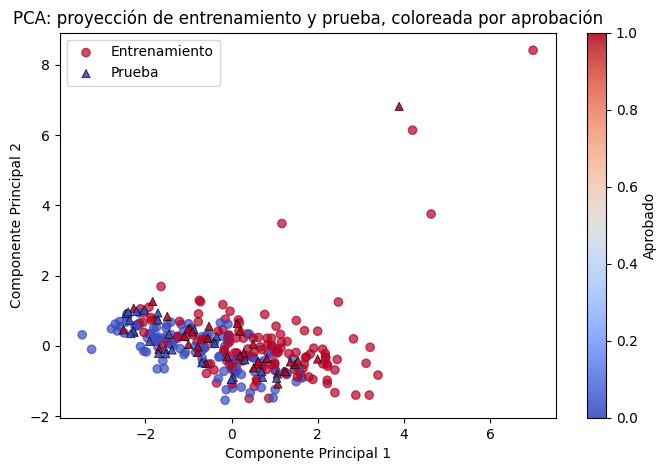

Varianza explicada por cada componente: [0.586 0.237]


In [58]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_train_scaled)  # Se ajusta SOLO con entrenamiento (ya estandarizado)

pca_train = pca.transform(X_train_scaled)
pca_test = pca.transform(X_test_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(pca_train[:, 0], pca_train[:, 1], c=y_train, cmap="coolwarm", alpha=0.7, marker="o", label="Entrenamiento")
plt.scatter(pca_test[:, 0], pca_test[:, 1], c=y_test, cmap="coolwarm", alpha=0.9, marker="^",
            edgecolor="black", linewidth=0.5, label="Prueba")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA: proyección de entrenamiento y prueba, coloreada por aprobación")
plt.legend()
plt.colorbar(label="Aprobado")
plt.show()

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_.round(3))

**¿Cómo elegir cuántos componentes conservar?** Un método habitual es graficar la **varianza acumulada** explicada a medida que se agregan componentes, y elegir el número de componentes donde esa curva alcanza un umbral deseado (por ejemplo, 90-95 % de la varianza total).

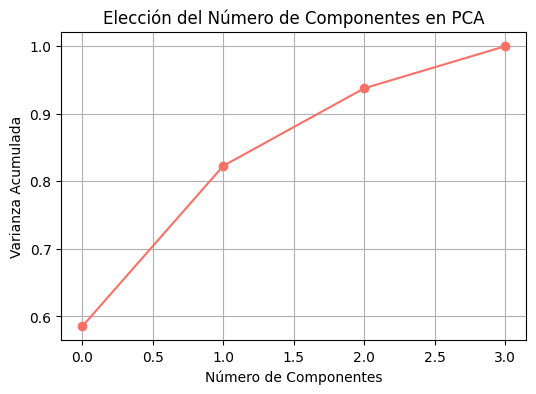

In [59]:
pca_completo = PCA().fit(X_train_scaled)

plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca_completo.explained_variance_ratio_), marker="o", color="#F97066")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Acumulada")
plt.title("Elección del Número de Componentes en PCA")
plt.grid()
plt.show()

---

<a id="preparacion"></a>

# <span style="color:#F97066;">8.</span> Validación adicional: cross-validation y train/val/test

El conjunto de prueba (`X_test`) ya quedó apartado desde la sección 1 y no ha participado en ningún ajuste. Esta sección presenta dos estrategias adicionales para evaluar un modelo de forma robusta **usando únicamente el conjunto de entrenamiento**.

### 8.1 Validación cruzada (*Cross-validation*)

Una única división entrenamiento/prueba depende de qué observaciones cayeron por azar en cada conjunto. La **validación cruzada de k-fold** divide el conjunto de entrenamiento en $k$ partes (*folds*), entrena $k$ veces usando $k-1$ partes y evalúa con la parte restante en cada ocasión, promediando los resultados: una estimación más robusta, obtenida sin tocar `X_test` en ningún momento.

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Ejecute la celda. Se combinan las variables numéricas ya estandarizadas con la codificación de <code>ciudad</code> y <code>nivel_educativo</code>, todas obtenidas exclusivamente a partir del entrenamiento.

In [60]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

X_train_modelo = pd.concat(
    [X_train_scaled, X_train[["nivel_educativo_cod"]], ciudad_train_encoded], axis=1
)

modelo = RandomForestClassifier(random_state=42)
scores = cross_val_score(modelo, X_train_modelo, y_train, cv=5)

print(f"Precisión media (validación cruzada, solo entrenamiento): {scores.mean():.2f}")
print("Precisión por fold:", scores.round(3))

Precisión media (validación cruzada, solo entrenamiento): 0.72
Precisión por fold: [0.792 0.75  0.667 0.729 0.688]


### 8.2 División en entrenamiento, validación y prueba (*Train / Validation / Test*)

Cuando además se necesita ajustar hiperparámetros del modelo, conviene reservar una porción adicional del **entrenamiento** como conjunto de **validación**, usado para comparar configuraciones del modelo sin tocar `X_test`, que se reserva únicamente para la evaluación final.

In [61]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_modelo, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f"Entrenamiento final: {X_train_final.shape[0]} filas")
print(f"Validación: {X_val.shape[0]} filas")
print(f"Prueba (apartada desde la sección 1): {X_test.shape[0]} filas")

Entrenamiento final: 180 filas
Validación: 60 filas
Prueba (apartada desde la sección 1): 60 filas


---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>
En este notebook se presentó el flujo completo de preprocesamiento de datos, usando un único dataset dividido en entrenamiento y prueba desde el inicio:

- Tratamiento de valores faltantes: eliminación (<code>dropna</code>) e imputación (media / moda), ajustada solo con entrenamiento.
- Detección de outliers (Z-score, boxplot) y su tratamiento (eliminación por IQR solo en entrenamiento, transformación logarítmica, winsorización con límites del entrenamiento).
- Escalado y normalización (Min-Max, estandarización), y cómo la media de la prueba escalada no da exactamente 0.
- Codificación de variables categóricas: ordinal para <code>nivel_educativo</code>, One-Hot para <code>ciudad</code>.
- Reducción de dimensionalidad con PCA, ajustado en entrenamiento y aplicado a prueba.
- Validación cruzada y partición train/validation/test, ambas realizadas exclusivamente dentro del entrenamiento.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>../1_ML_implementation.ipynb</code> — con los datos ya explorados y preprocesados correctamente, el siguiente paso es entrenar y evaluar un modelo de Machine Learning.</li>
</ul>
</div>